# Soft Voting Ensemble Model for Medical Deepfake Detection

This notebook implements a concatentation ensemble combining three pretrained architectures (VGG-16, DenseNet-121, EfficientNet-B0) to classify CT scan slices from the Medical Deepfakes Lung Cancer dataset.

## Ensemble Architecture Overview:

**Concatenation Strategy**: Combines predictions from multiple models by collecting each model's features.

### Three Base Models (All Frozen):
1. **VGG16**: Deep CNN with 16 layers, known for strong feature extraction
2. **DenseNet121**: Dense connections between layers, efficient feature reuse
3. **EfficientNetB0**: Balanced depth, width, and resolution scaling

### Pipeline Architecture:
- **Input**: 512×512×3 RGB images
- **Data Augmentation**: Random horizontal flip and rotation (applied once)
- **Model-Specific Preprocessing**: Each model uses its own ImageNet preprocessing
- **Feature Extraction**: Flatten outputs from all three models
- **Feature Fusion**: Concatenate all features into single vector
- **Classification Head**: Dense(256) → Dropout(0.5) → Dense(4, softmax)

## Pipeline Steps:
1. Mount Google Drive and install dependencies
2. Build ensemble architecture with frozen base models
3. Load and split dataset (70% train, 15% val, 15% test)
4. Create balanced class subsets
5. Train ensemble with callbacks (early stopping, learning rate reduction)
6. Visualize training history
7. Evaluate on validation and test sets with comprehensive metrics

In [ ]:
# Mount Google Drive to access the dataset
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

## Import Required Libraries

Install and import TensorFlow/Keras for building the ensemble model, along with the three pretrained architectures.

In [ ]:
import os

# Install TensorFlow if not already available
!pip install tensorflow

# Core TensorFlow and Keras imports
import tensorflow as tf
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Concatenate, Dropout, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.applications import DenseNet121, VGG16, EfficientNetV2B0
from tensorflow.keras.utils import image_dataset_from_directory, Sequence
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam
import numpy as np

## Build Concatenation Ensemble Architecture

This cell constructs the ensemble model that combines VGG16, DenseNet121, and EfficientNetB0.

### Key Design Choices:

**Model-Specific Preprocessing**: Each architecture expects different input normalization (from ImageNet training), so we apply model-specific preprocessing using Lambda layers.

**Frozen Base Models**: All three pretrained models have `trainable=False` to preserve ImageNet features and prevent overfitting.

**Feature Fusion**: Features from all models are flattened and concatenated into a single feature vector before classification.

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16, DenseNet121, EfficientNetB0
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as dense_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout, Concatenate, Lambda
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, RandomContrast
from tensorflow.keras.models import Model

IMG_SIZE = 512
num_classes = 4

# Input layer
inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Data augmentation
# Applied once before model-specific preprocessing
data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.05)
], name="augmentation")

augmented = data_augmentation(inputs)

# Model specific preprocessing
# Each pretrained model expects different input normalization from ImageNet training
vgg_in   = Lambda(vgg_preprocess, name="vgg_preprocess")(augmented)
dense_in = Lambda(dense_preprocess, name="densenet_preprocess")(augmented)
eff_in   = Lambda(eff_preprocess, name="effnet_preprocess")(augmented)

# Load pretrained models
# include_top=False removes the original ImageNet classification head
# weights='imagenet' loads pretrained weights
vgg = VGG16(include_top=False, weights='imagenet', input_tensor=vgg_in)
densenet = DenseNet121(include_top=False, weights='imagenet', input_tensor=dense_in)
effnet = EfficientNetB0(include_top=False, weights='imagenet', input_tensor=eff_in)

# Freeze all base model weights to use as feature extractors
for m in [vgg, densenet, effnet]:
    m.trainable = False

# Feature extraction
# Flatten spatial feature maps into 1D vectors
vgg_feat = Flatten()(vgg.output)
dense_feat = Flatten()(densenet.output)
eff_feat = Flatten()(effnet.output)

# Combine all features into a single vector for classification
combined = Concatenate()([vgg_feat, dense_feat, eff_feat])

# This head learns to combine features from all three models
x = Dense(256, activation='relu')(combined)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation='softmax')(x)

# Build the complete ensemble model
model = Model(inputs, output)

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss='categorical_crossentropy', # Changed to categorical_crossentropy
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 512, 512,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet_preprocess │ (None, 512, 512,  │          0 │ augmentation[0][… │
│ (Lambda)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 518, 518,  │          0 │ densenet_preproc… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 256, 256,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 256, 256,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 256, 256,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 258, 258,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 128, 128,  │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 128, 128,  │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 128, 128,  │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 128, 128,  │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 128, 128,  │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 128, 128,  │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 128, 128,  │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 128, 128,  │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 128, 128,  │        384 │ conv2_block1_con

 Total params: 210,352,423 (802.43 MB)

 Trainable params: 184,550,660 (704.00 MB)

 Non-trainable params: 25,801,763 (98.43 MB)

## Dataset Loading and Splitting

Load the complete dataset and split into training (70%), validation (15%), and test (15%) sets.

**Important**: We use the same splitting strategy as the baseline models to ensure fair comparison.

In [ ]:
# Load the FULL dataset first (no split)
# batch_size=None ensures we load individual samples for proper splitting
full_ds = image_dataset_from_directory(
    "/content/drive/MyDrive/CT_PNG_512",
    label_mode='categorical',
    seed=123,
    image_size=(512, 512),
    batch_size=None,
    shuffle=True
)

# Get total dataset size
total_samples = full_ds.cardinality().numpy()
print(f"Total samples in dataset: {total_samples}")

# Define split ratios: 70% train, 15% validation, 15% test
train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

# Calculate split sizes
train_size = int(total_samples * train_ratio)
val_size = int(total_samples * val_ratio)
test_size = total_samples - train_size - val_size

print(f"Split sizes - Train: {train_size}, Val: {val_size}, Test: {test_size}")

# Shuffle and split the dataset
# Using a buffer size equal to dataset size for perfect shuffle
full_ds_shuffled = full_ds.shuffle(buffer_size=total_samples, seed=123, reshuffle_each_iteration=False)

# Split into train, val, test
train_ds_raw = full_ds_shuffled.take(train_size)
remaining = full_ds_shuffled.skip(train_size)
val_ds_raw = remaining.take(val_size)
test_ds_raw = remaining.skip(val_size)

# Batch the datasets for efficient training
batch_size = 32
train_ds = train_ds_raw.batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds_raw.batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds_raw.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Verify the splits have no overlap by checking sizes
print(f"\nVerifying split sizes:")
print(f"  Train batches: {train_ds.cardinality().numpy()} (approx {train_size} samples)")
print(f"  Val batches: {val_ds.cardinality().numpy()} (approx {val_size} samples)")
print(f"  Test batches: {test_ds.cardinality().numpy()} (approx {test_size} samples)")

Found 17457 files belonging to 4 classes.
Total samples in dataset: 17457
Split sizes - Train: 12219, Val: 2618, Test: 2620

Verifying split sizes:
  Train batches: 382 (approx 12219 samples)
  Val batches: 82 (approx 2618 samples)
  Test batches: 82 (approx 2620 samples)


## Creating Balanced Class Subsets

Create balanced subsets with equal representation from each of the 4 classes to prevent model bias toward the majority class.

This is especially important for ensemble models, as class imbalance can cause different base models to favor different classes, leading to inconsistent predictions.

In [ ]:
# Create balanced subsets of the datasets
# Ensures equal representation from each class
import numpy as np

# Set random seed for reproducibility
np.random.seed(123)

def create_balanced_subset(dataset, total_samples, batch_size=32):
    """
    Create a balanced subset with equal samples from each class.
    For 4 classes, takes total_samples/4 from each class.

    Args:
        dataset: TensorFlow dataset to balance
        total_samples: Target total number of samples
        batch_size: Batch size for the output dataset

    Returns:
        balanced_ds: Balanced TensorFlow dataset
        samples_per_class: Number of samples taken from each class
    """
    samples_per_class = total_samples // 4

    # Collect samples by class
    class_images = {0: [], 1: [], 2: [], 3: []}
    class_labels = {0: [], 1: [], 2: [], 3: []}

    # Iterate through dataset and collect samples for each class
    for images, labels in dataset.unbatch():
        class_idx = np.argmax(labels.numpy())

        # Add to the appropriate class if we haven't collected enough yet
        if len(class_images[class_idx]) < samples_per_class:
            class_images[class_idx].append(images.numpy())
            class_labels[class_idx].append(labels.numpy())

        # Stop if all classes have enough samples
        if all(len(class_images[c]) >= samples_per_class for c in range(4)):
            break

    # Combine all classes
    all_images = []
    all_labels = []
    for c in range(4):
        all_images.extend(class_images[c])
        all_labels.extend(class_labels[c])

    # Convert to numpy arrays
    all_images = np.array(all_images)
    all_labels = np.array(all_labels)

    # Shuffle the combined dataset
    indices = np.random.permutation(len(all_images))
    all_images = all_images[indices]
    all_labels = all_labels[indices]

    # Create TensorFlow dataset
    balanced_ds = tf.data.Dataset.from_tensor_slices((all_images, all_labels))
    balanced_ds = balanced_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return balanced_ds, samples_per_class

# Create balanced subsets
print("Creating balanced training subset...")
train_subset_ds, train_per_class = create_balanced_subset(train_ds, total_samples=1932, batch_size=32)

print("Creating balanced validation subset...")
val_subset_ds, val_per_class = create_balanced_subset(val_ds, total_samples=828, batch_size=32)

print("Creating balanced test subset...")
test_subset_ds, test_per_class = create_balanced_subset(test_ds, total_samples=852, batch_size=32)

print(f"\nBalanced subsets created:")
print(f"Training: {train_per_class} samples per class × 4 classes = {train_per_class * 4} total")
print(f"Validation: {val_per_class} samples per class × 4 classes = {val_per_class * 4} total")
print(f"Test: {test_per_class} samples per class × 4 classes = {test_per_class * 4} total")

# Verify class distributions
def verify_distribution(dataset, name):
    class_counts = np.zeros(4, dtype=int)
    for _, labels in dataset:
        class_indices = np.argmax(labels.numpy(), axis=1)
        for idx in class_indices:
            class_counts[idx] += 1
    print(f"\n{name} class distribution:")
    for i in range(4):
        print(f"  Class {i}: {class_counts[i]} samples")
    return class_counts

print("\nVerifying class distributions...")
train_class_counts = verify_distribution(train_subset_ds, "Training subset")
val_class_counts = verify_distribution(val_subset_ds, "Validation subset")
test_class_counts = verify_distribution(test_subset_ds, "Test subset")

Creating balanced training subset...
Creating balanced validation subset...
Creating balanced test subset...

Balanced subsets created:
Training: 483 samples per class × 4 classes = 1932 total
Validation: 207 samples per class × 4 classes = 828 total
Test: 213 samples per class × 4 classes = 852 total

Verifying class distributions...

Training subset class distribution:
  Class 0: 483 samples
  Class 1: 483 samples
  Class 2: 483 samples
  Class 3: 483 samples

Validation subset class distribution:
  Class 0: 207 samples
  Class 1: 207 samples
  Class 2: 207 samples
  Class 3: 207 samples

Test subset class distribution:
  Class 0: 213 samples
  Class 1: 213 samples
  Class 2: 213 samples
  Class 3: 213 samples


## Custom Callback: Early Stopping at Target Accuracy

This custom callback stops training when validation accuracy reaches a target threshold (95%), preventing unnecessary training and potential overfitting.

In [ ]:
# Custom callback to stop training when target accuracy is reached
class StopAtAccuracy(tf.keras.callbacks.Callback):
    """
    Stop training when validation accuracy reaches or exceeds the target.

    Args:
        target: Target validation accuracy (default: 0.94 = 94%)
    """
    def __init__(self, target=0.94):
        super().__init__()
        self.target = target

    def on_epoch_end(self, epoch, logs=None):
        acc = logs.get("val_accuracy")
        if acc is not None and acc >= self.target:
            print(f"\nReached {self.target*100}% validation accuracy. Stopping training...")
            self.model.stop_training = True

## Train the Ensemble Model

Train the ensemble with multiple callbacks for robust training:

**Callbacks**:
1. **ReduceLROnPlateau**: Reduce learning rate by 50% if validation loss plateaus for 3 epochs
2. **ModelCheckpoint**: Save best model based on validation accuracy
3. **EarlyStopping**: Stop if validation loss doesn't improve for 6 epochs, restore best weights
4. **StopAtAccuracy**: Stop early if 95% validation accuracy is reached

These callbacks help prevent overfitting and ensure we get the best possible model.

In [ ]:
# Train the ensemble model with multiple callbacks
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7),
    tf.keras.callbacks.ModelCheckpoint("best_model.h5", save_best_only=True, monitor="val_accuracy"),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    StopAtAccuracy(target=0.95)
]

# Train the model
history_ensemble = model.fit(
    train_subset_ds,
    validation_data=val_subset_ds,
    epochs=25,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/25
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.4368 - loss: 10.7931 - precision: 0.4521 - recall: 0.4154

61/61 ━━━━━━━━━━━━━━━━━━━━ 78s 783ms/step - accuracy: 0.4380 - loss: 10.7052 - precision: 0.4539 - recall: 0.4158 - val_accuracy: 0.6848 - val_loss: 0.7316 - val_precision: 0.8406 - val_recall: 0.5157 - learning_rate: 5.0000e-05
Epoch 2/25
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.6421 - loss: 0.7890 - precision: 0.8082 - recall: 0.5155

61/61 ━━━━━━━━━━━━━━━━━━━━ 29s 476ms/step - accuracy: 0.6418 - loss: 0.7893 - precision: 0.8080 - recall: 0.5153 - val_accuracy: 0.7705 - val_loss: 0.6089 - val_precision: 0.8477 - val_recall: 0.6522 - learning_rate: 5.0000e-05
Epoch 3/25
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.7168 - loss: 0.6704 - precision: 0.8349 - recall: 0.6139

61/61 ━━━━━━━━━━━━━━━━━━━━ 29s 477ms/step - accuracy: 0.7166 - loss: 0.6706 - precision: 0.8348 - recall: 0.6136 - val_accuracy: 0.7862 - val_loss: 0.5318 - val_precision: 0.8647 - val_recall: 0.6872 - learning_rate: 5.0000e-05
Epoch 4/25
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.7556 - loss: 0.5703 - precision: 0.8354 - recall: 0.6676

61/61 ━━━━━━━━━━━━━━━━━━━━ 29s 475ms/step - accuracy: 0.7557 - loss: 0.5701 - precision: 0.8355 - recall: 0.6678 - val_accuracy: 0.8490 - val_loss: 0.3513 - val_precision: 0.8912 - val_recall: 0.8116 - learning_rate: 5.0000e-05
Epoch 5/25
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.7884 - loss: 0.4727 - precision: 0.8817 - recall: 0.7255

61/61 ━━━━━━━━━━━━━━━━━━━━ 33s 543ms/step - accuracy: 0.7886 - loss: 0.4725 - precision: 0.8817 - recall: 0.7258 - val_accuracy: 0.8913 - val_loss: 0.3010 - val_precision: 0.9018 - val_recall: 0.8539 - learning_rate: 5.0000e-05
Epoch 6/25
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.8299 - loss: 0.4153 - precision: 0.8855 - recall: 0.7861

61/61 ━━━━━━━━━━━━━━━━━━━━ 29s 479ms/step - accuracy: 0.8296 - loss: 0.4156 - precision: 0.8854 - recall: 0.7857 - val_accuracy: 0.9070 - val_loss: 0.2699 - val_precision: 0.9301 - val_recall: 0.8841 - learning_rate: 5.0000e-05
Epoch 7/25
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.8259 - loss: 0.4055 - precision: 0.8779 - recall: 0.7820

61/61 ━━━━━━━━━━━━━━━━━━━━ 30s 499ms/step - accuracy: 0.8261 - loss: 0.4052 - precision: 0.8780 - recall: 0.7823 - val_accuracy: 0.9275 - val_loss: 0.1908 - val_precision: 0.9370 - val_recall: 0.9167 - learning_rate: 5.0000e-05
Epoch 8/25
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.8591 - loss: 0.3605 - precision: 0.9009 - recall: 0.8292

61/61 ━━━━━━━━━━━━━━━━━━━━ 29s 485ms/step - accuracy: 0.8589 - loss: 0.3604 - precision: 0.9009 - recall: 0.8291 - val_accuracy: 0.9408 - val_loss: 0.1707 - val_precision: 0.9576 - val_recall: 0.9275 - learning_rate: 5.0000e-05
Epoch 9/25
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.8709 - loss: 0.2884 - precision: 0.9215 - recall: 0.8485


Reached 95.0% validation accuracy. Stopping training...
61/61 ━━━━━━━━━━━━━━━━━━━━ 29s 475ms/step - accuracy: 0.8708 - loss: 0.2887 - precision: 0.9214 - recall: 0.8484 - val_accuracy: 0.9565 - val_loss: 0.1293 - val_precision: 0.9629 - val_recall: 0.9408 - learning_rate: 5.0000e-05


## Visualize Training History

Plot training and validation metrics over epochs to assess model learning and detect overfitting.

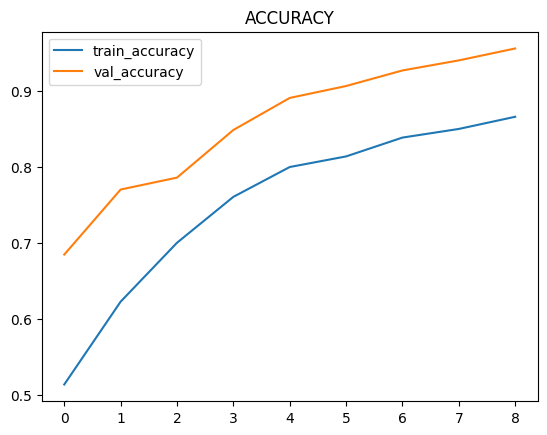

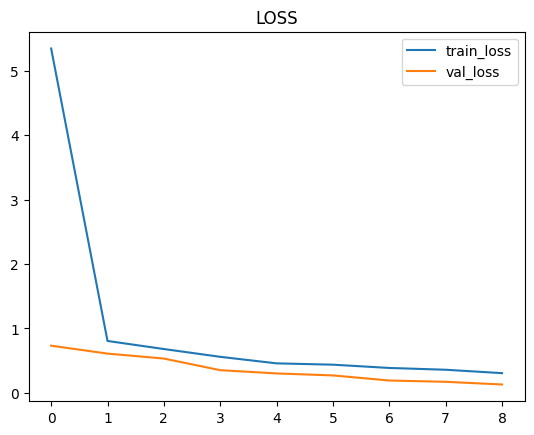

In [ ]:
# Visualize training history
import matplotlib.pyplot as plt

hist = history_ensemble

def plot_metric(name):
    """Plot training and validation curves for a specific metric."""
    plt.plot(hist.history[name], label=f"train_{name}")
    plt.plot(hist.history["val_"+name], label=f"val_{name}")
    plt.title(name.upper())
    plt.legend()
    plt.show()

# Plot accuracy and loss curves
plot_metric("accuracy")
plot_metric("loss")

## Validation Set Evaluation

Evaluate the trained ensemble on the validation set to get initial performance metrics.

In [ ]:
# Evaluate the ensemble model on validation set
val_loss, val_accuracy, val_precision, val_recall = model.evaluate(val_subset_ds)
print(f"\nValidation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation Precision: {val_precision:.4f}")
print(f"Validation Recall: {val_recall:.4f}")

26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 247ms/step - accuracy: 0.9546 - loss: 0.1376 - precision: 0.9611 - recall: 0.9307

Validation Loss: 0.1293
Validation Accuracy: 0.9565
Validation Precision: 0.9629
Validation Recall: 0.9408


## Validation Predictions and Confusion Matrix

Generate predictions and visualize the confusion matrix to understand per-class performance and common misclassifications.

26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 507ms/step
Predicted 828 samples
Prediction distribution: [199 204 218 207]


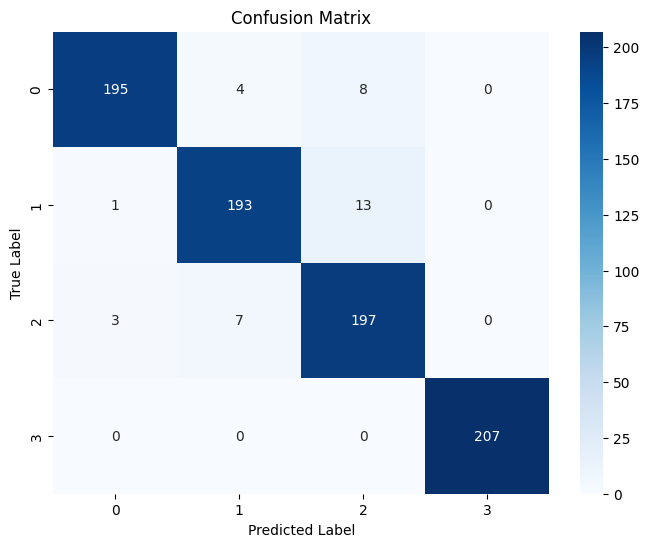

In [ ]:
import itertools
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions on validation subset
y_pred_probs = model.predict(val_subset_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

print(f"Predicted {len(y_pred)} samples")
print(f"Prediction distribution: {np.bincount(y_pred)}")

# Get true labels from the validation dataset
y_true = np.concatenate([np.argmax(y, axis=1) for x, y in val_subset_ds], axis=0)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## Final Test Set Evaluation

Evaluate the ensemble on the held-out test set to assess real-world performance. This provides:
- **Overall metrics**: Loss, accuracy, precision, recall
- **Confusion matrix**: Per-class performance visualization
- **Classification report**: Detailed per-class metrics including F1-scores

The test set was not used during training or model selection, providing an unbiased estimate of model performance.

FINAL TEST SET EVALUATION
27/27 ━━━━━━━━━━━━━━━━━━━━ 9s 328ms/step - accuracy: 0.9644 - loss: 0.1135 - precision: 0.9744 - recall: 0.9577

Test Loss: 0.1227
Test Accuracy: 0.9589
Test Precision: 0.9688
Test Recall: 0.9484
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 242ms/step


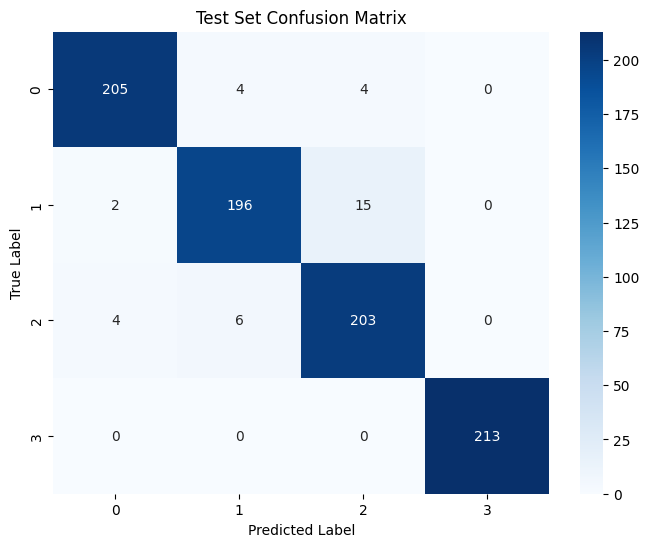


Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       213
           1       0.95      0.92      0.94       213
           2       0.91      0.95      0.93       213
           3       1.00      1.00      1.00       213

    accuracy                           0.96       852
   macro avg       0.96      0.96      0.96       852
weighted avg       0.96      0.96      0.96       852



In [ ]:
# Final evaluation on TEST set (held-out data)
print("="*50)
print("FINAL TEST SET EVALUATION")
print("="*50)

# Evaluate ensemble model on test set
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(test_subset_ds)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")

# Generate predictions for confusion matrix
y_test_pred_probs = model.predict(test_subset_ds)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)
y_test_true = np.concatenate([np.argmax(y, axis=1) for x, y in test_subset_ds], axis=0)

# Compute and plot confusion matrix for test set
cm_test = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Test Set Confusion Matrix')
plt.show()

# Generate detailed classification report
from sklearn.metrics import classification_report
print("\nClassification Report (Test Set):")
print(classification_report(y_test_true, y_test_pred))